# Project 2.2 — Is it better to use a Muxponder or an Uplink?

**Course:** Communication and Network Design — PoliMi–Nokia Vimercate 2025/2026

---

## Goal

> Compare the **maximum capacity** of the network depending on the used multilayer devices (Uplinks vs Xponders/Muxponders). Which OTN switch constraint (capacity or number of ports) has more impact on network capacity?

## Approach

We implement three solution methods with increasing quality:

| Method | Description | Speed |
|--------|-------------|-------|
| **Baseline** | First-fit, arrival order, shortest path | ~ms |
| **Heuristic** | Shortest-path-first sorting + greedy | ~ms |
| **ILP** | Integer Linear Programming (CBC solver) | ~s to min |

Each is tested under 4 configurations:
- **Uplink without grooming** — each demand gets its own lightpath
- **Uplink with grooming** — demands share lightpath capacity
- **Xponder without grooming** — each demand gets its own lightpath  
- **Xponder with grooming** — demands share lightpath capacity

**Maximum capacity** is defined as the maximum number of services that can be routed before the blocking rate reaches 1%.

## Key Architectural Difference

### Uplink
- Plugged **directly** into the OTN matrix
- Each uplink reserves **500 Gb/s** of OTN switch capacity
- Each uplink uses **1 OTN switch port**
- Carrying 1 Tb/s requires 4 uplinks → **2000 Gb/s** reserved, **4 ports**

### Xponder (Muxponder)  
- Connected to OTN matrix via **I/O cards** (1000 Gb/s, 10 slots each)
- Each I/O card uses **1 OTN switch port** and reserves **1000 Gb/s**
- Carrying 1 Tb/s requires 4 xponders on 1 card → **1000 Gb/s** reserved, **1 port**

**The xponder architecture uses 2× less OTN capacity and 4× fewer ports for the same traffic.**

## 1. Setup: Imports and Network Parameters (from PDF Section 3)

In [3]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import math, random, time, pulp
from itertools import islice
from collections import defaultdict
from copy import deepcopy
import warnings
warnings.filterwarnings('ignore')

SEED = 42

# ════════════════════════════════════════════════════════════
# PDF Constants (Section 3 + Project 2.2, pages 7-9)
# ════════════════════════════════════════════════════════════

# Modulation table (Section 3.3): (rate_gbps, spacing_ghz, reach_km)
MODULATION_TABLE = [
    (800, 100, 150), (700, 100, 400), (600, 100, 700),
    (500, 100, 1300), (400, 100, 2500), (300, 100, 4700),
    (300, 50, 100), (200, 50, 900), (100, 50, 3000),
]

C_BAND_CHANNELS = 96   # 4.8 THz / 50 GHz

# OTN switch (single layer for Project 2.2)
OTN_CAP   = 12_000     # 12 Tb/s total switching capacity
OTN_PORTS = 70          # max ports
OTN_ODUS  = 100         # max ODU frames

# Client I/O card (L2/3 ↔ L1)
CIO_CAP   = 100         # reserved capacity per card (Gb/s)
CIO_PORTS = 10          # client-facing ports per card

# Uplink (direct plug into OTN matrix)
UPL_CAP   = 500         # reserved capacity per uplink (Gb/s)

# Xponder I/O card (L1 ↔ Xponders)
XIO_CAP   = 1000        # reserved capacity per card (Gb/s)
XIO_SLOTS = 10          # xponder slots per card

# Signal quality limit (from PDF example Fig. 4)
MAX_TRX   = 250         # max transponder rate (Gb/s)

RATES = [10, 100]       # client service rates

def max_lp_rate(dist_km):
    """Max lightpath rate achievable at given distance (capped by signal quality)."""
    best = 0
    for rate, sp, reach in MODULATION_TABLE:
        if reach >= dist_km:
            best = max(best, rate)
    return min(best, MAX_TRX) if best > 0 else 100

print("Parameters loaded successfully.")
print(f"  OTN switch: {OTN_CAP/1000:.0f} Tb/s capacity, {OTN_PORTS} ports, {OTN_ODUS} ODUs")
print(f"  Uplink: {UPL_CAP} Gb/s reserved per unit")
print(f"  Xponder I/O card: {XIO_CAP} Gb/s reserved, {XIO_SLOTS} slots")
print(f"  Max transponder rate: {MAX_TRX} Gb/s")
print(f"  C-band channels: {C_BAND_CHANNELS}")

Parameters loaded successfully.
  OTN switch: 12 Tb/s capacity, 70 ports, 100 ODUs
  Uplink: 500 Gb/s reserved per unit
  Xponder I/O card: 1000 Gb/s reserved, 10 slots
  Max transponder rate: 250 Gb/s
  C-band channels: 96


## 2. Network Topologies

Per the PDF (Section 3.1), we test on:
- **Continental network**: ≥20 links, avg link ~300 km, max ~1000 km  
- **National network**: ≤20 links, avg link ~150 km, max ~400 km

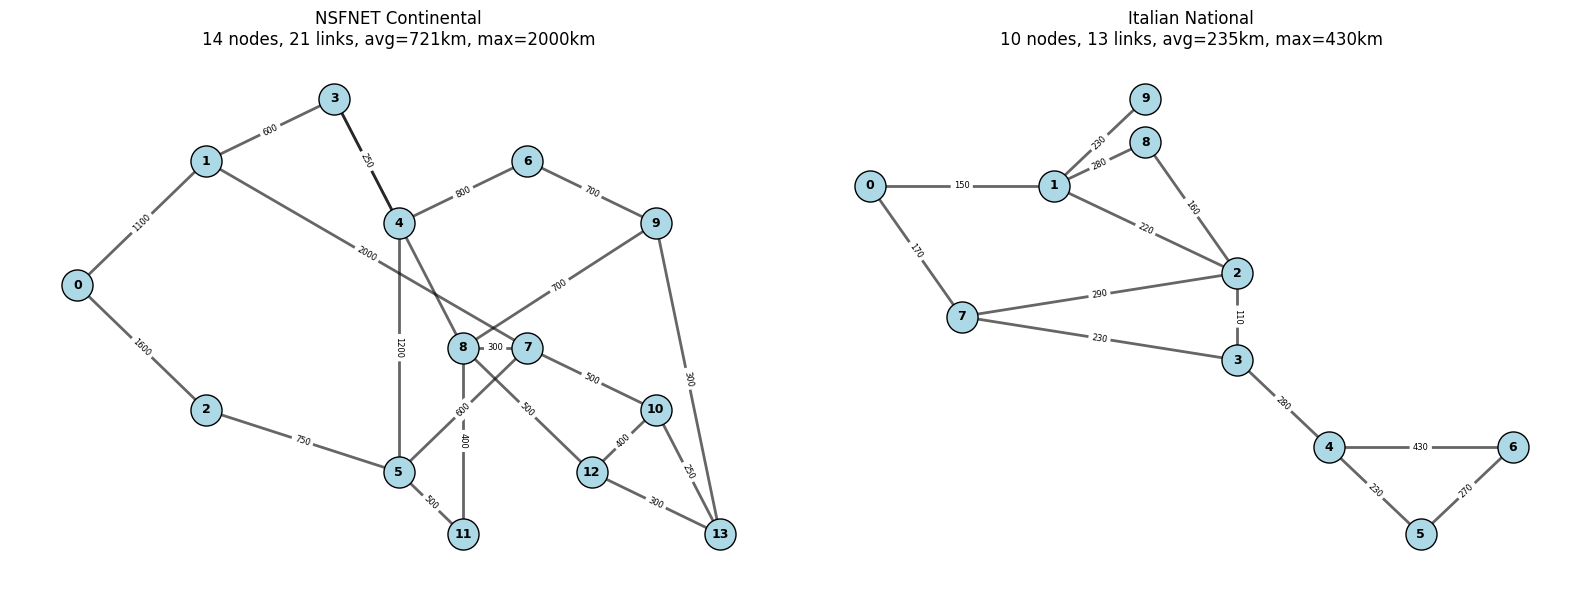

In [4]:
def nsfnet():
    """14-node NSFNET — Continental topology."""
    G = nx.Graph()
    for i in range(14): G.add_node(i)
    links = [
        (0,1,1100),(0,2,1600),(1,3,600),(1,7,2000),
        (2,5,750),(3,4,250),(3,8,1400),(4,5,1200),
        (4,6,800),(5,7,600),(5,11,500),(6,9,700),
        (7,8,300),(7,10,500),(8,9,700),(8,11,400),
        (8,12,500),(9,13,300),(10,12,400),(10,13,250),(12,13,300),
    ]
    for u,v,d in links:
        G.add_edge(u,v, length_km=d)
    pos = {0:(-2.5,1),1:(-1.5,2),2:(-1.5,0),3:(-0.5,2.5),4:(0,1.5),
           5:(0,-0.5),6:(1,2),7:(1,0.5),8:(0.5,0.5),9:(2,1.5),
           10:(2,0),11:(0.5,-1),12:(1.5,-0.5),13:(2.5,-1)}
    nx.set_node_attributes(G, pos, "pos")
    return G

def italian():
    """10-node Italian backbone — National topology."""
    G = nx.Graph()
    for i in range(10): G.add_node(i)
    links = [
        (0,1,150),(0,7,170),(1,2,220),(1,8,280),(1,9,230),
        (2,3,110),(2,8,160),(3,4,280),(3,7,230),(4,5,230),
        (4,6,430),(5,6,270),(7,2,290),
    ]
    for u,v,d in links:
        G.add_edge(u,v, length_km=d)
    pos = {0:(0,3),1:(2,3),2:(4,2),3:(4,1),4:(5,0),
           5:(6,-1),6:(7,0),7:(1,1.5),8:(3,3.5),9:(3,4)}
    nx.set_node_attributes(G, pos, "pos")
    return G

# Plot both
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, (name, G) in zip(axes, [("NSFNET Continental", nsfnet()), ("Italian National", italian())]):
    pos = nx.get_node_attributes(G, "pos")
    lens = [d["length_km"] for _,_,d in G.edges(data=True)]
    nx.draw_networkx_nodes(G, pos, node_size=500, node_color="lightblue", edgecolors="black", ax=ax)
    nx.draw_networkx_edges(G, pos, width=2, alpha=0.6, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=9, font_weight="bold", ax=ax)
    edge_labels = {(u,v): f'{d["length_km"]:.0f}' for u,v,d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=6, ax=ax)
    ax.set_title(f"{name}\n{G.number_of_nodes()} nodes, {G.number_of_edges()} links, "
                 f"avg={np.mean(lens):.0f}km, max={max(lens):.0f}km", fontsize=12)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 3. Simulation Engine

### 3.1 Demand Generation and Path Computation

Services are generated between random source-destination pairs with rates of 10 or 100 Gb/s (50/50 distribution). For each demand, we precompute the $k=3$ shortest paths.

In [5]:
def gen_demands(G, n, seed=42):
    """Generate n random demands with 50/50 rate distribution."""
    rng = random.Random(seed)
    nodes = list(G.nodes)
    return [{"id":i, "src":rng.sample(nodes,2)[0], "dst":rng.sample(nodes,2)[1],
             "rate": rng.choices(RATES, weights=(0.5,0.5))[0]} for i in range(n)]

def k_shortest(G, demands, k=3):
    """Compute k shortest paths for each demand."""
    paths = {}
    for d in demands:
        try:
            ps = list(islice(nx.shortest_simple_paths(G, d["src"], d["dst"], weight="length_km"), k))
        except nx.NetworkXNoPath:
            ps = []
        paths[d["id"]] = ps
    return paths

def pedges(path):
    return [(min(path[i],path[i+1]), max(path[i],path[i+1])) for i in range(len(path)-1)]

def pdist(G, path):
    return sum(G[path[i]][path[i+1]]["length_km"] for i in range(len(path)-1))

print("Demand/path utilities loaded.")

Demand/path utilities loaded.


### 3.2 OTN Node State Tracking

Each node tracks: ODU count, client I/O cards, port usage, transponders, reserved capacity.
The key difference between Uplink and Xponder is in `add_trx()`:
- **Uplink**: each transponder reserves 500 Gb/s and uses 1 port directly
- **Xponder**: transponders are grouped into I/O cards (10 per card), each card reserves 1000 Gb/s and uses 1 port

In [6]:
class NodeState:
    """OTN switch state at one node."""
    def __init__(self, scenario):
        self.scenario = scenario
        self.odu = 0
        self.cio_cards = 0      # client I/O cards
        self.cio_used = 0       # client port-equivalents used
        self.trx = 0            # transponders
        self.xio_cards = 0      # xponder I/O cards (xponder only)
        self.res_cap = 0        # reserved capacity (Gb/s)

    def ports_used(self):
        if self.scenario == "uplink":
            return self.cio_cards + self.trx
        else:
            return self.cio_cards + self.xio_cards

    def can_add_client(self, rate):
        peq = 1 if rate == 10 else 10
        if self.odu + 1 > OTN_ODUS: return False
        if self.cio_used + peq > self.cio_cards * CIO_PORTS:
            if self.ports_used() + 1 > OTN_PORTS: return False
            if self.res_cap + CIO_CAP > OTN_CAP: return False
        return True

    def add_client(self, rate):
        peq = 1 if rate == 10 else 10
        if self.cio_used + peq > self.cio_cards * CIO_PORTS:
            self.cio_cards += 1
            self.res_cap += CIO_CAP
        self.cio_used += peq
        self.odu += 1

    def can_add_trx(self):
        if self.scenario == "uplink":
            return (self.ports_used() + 1 <= OTN_PORTS and
                    self.res_cap + UPL_CAP <= OTN_CAP)
        else:
            if self.trx + 1 > self.xio_cards * XIO_SLOTS:
                return (self.ports_used() + 1 <= OTN_PORTS and
                        self.res_cap + XIO_CAP <= OTN_CAP)
            return True

    def add_trx(self):
        if self.scenario == "uplink":
            self.res_cap += UPL_CAP
            self.trx += 1
        else:
            if self.trx + 1 > self.xio_cards * XIO_SLOTS:
                self.xio_cards += 1
                self.res_cap += XIO_CAP
            self.trx += 1

    def can_transit(self):
        return self.odu + 1 <= OTN_ODUS

    def add_transit(self):
        self.odu += 1


class NetState:
    """Full network state: OTN nodes + WDM edges."""
    def __init__(self, G, scenario):
        self.G = G
        self.scenario = scenario
        self.nodes = {v: NodeState(scenario) for v in G.nodes}
        self.lps = {(min(u,v),max(u,v)): [] for u,v in G.edges}

    def try_route(self, demand, path, grooming=False):
        rate = demand["rate"]
        src, dst = path[0], path[-1]
        edges = pedges(path)
        transit = path[1:-1]

        # Feasibility
        if not self.nodes[src].can_add_client(rate): return False
        if not self.nodes[dst].can_add_client(rate): return False
        for v in transit:
            if not self.nodes[v].can_transit(): return False

        if grooming:
            new_lp_edges = []
            for e in edges:
                spare = sum(c - u for c, u in self.lps[e])
                if spare >= rate: continue
                if len(self.lps[e]) >= C_BAND_CHANNELS: return False
                if not self.nodes[e[0]].can_add_trx(): return False
                if not self.nodes[e[1]].can_add_trx(): return False
                new_lp_edges.append(e)

            # Commit
            self.nodes[src].add_client(rate)
            self.nodes[dst].add_client(rate)
            for v in transit: self.nodes[v].add_transit()
            for e in edges:
                if e in new_lp_edges:
                    lp_cap = max_lp_rate(self.G[e[0]][e[1]]["length_km"])
                    self.lps[e].append([lp_cap, rate])
                    self.nodes[e[0]].add_trx()
                    self.nodes[e[1]].add_trx()
                else:
                    for lp in self.lps[e]:
                        if lp[0] - lp[1] >= rate:
                            lp[1] += rate
                            break
            return True
        else:
            for e in edges:
                if len(self.lps[e]) >= C_BAND_CHANNELS: return False
                if not self.nodes[e[0]].can_add_trx(): return False
                if not self.nodes[e[1]].can_add_trx(): return False
            self.nodes[src].add_client(rate)
            self.nodes[dst].add_client(rate)
            for v in transit: self.nodes[v].add_transit()
            for e in edges:
                lp_cap = max_lp_rate(self.G[e[0]][e[1]]["length_km"])
                self.lps[e].append([lp_cap, rate])
                self.nodes[e[0]].add_trx()
                self.nodes[e[1]].add_trx()
            return True

    def bottleneck_data(self):
        return {v: {"odu": n.odu/OTN_ODUS*100, "ports": n.ports_used()/OTN_PORTS*100,
                     "cap": n.res_cap/OTN_CAP*100} for v, n in self.nodes.items()}

    def stats(self):
        return {"channels": sum(len(l) for l in self.lps.values()),
                "transponders": sum(n.trx for n in self.nodes.values()),
                "client_io": sum(n.cio_cards for n in self.nodes.values()),
                "xponder_io": sum(n.xio_cards for n in self.nodes.values())}

print("Network state engine loaded.")

Network state engine loaded.


### 3.3 Solution Methods

**Baseline**: Route demands in arrival order using first-fit on k-shortest paths.

**Heuristic**: Sort demands shortest-path-first, then apply first-fit. Short demands consume fewer resources per service, leaving more room for later demands.

**ILP**: Maximize the number of accepted services using Integer Linear Programming. This gives the theoretical optimum but is computationally expensive.

In [7]:
# ── Baseline ──
def run_baseline(G, demands, paths, scenario, grooming):
    state = NetState(G, scenario)
    accepted = []
    for d in demands:
        for p in paths[d["id"]]:
            if state.try_route(d, p, grooming):
                accepted.append(d); break
    n = len(demands)
    return {"accepted": len(accepted), "blocked": n-len(accepted),
            "br": (n-len(accepted))/n if n else 0,
            "carried": sum(d["rate"] for d in accepted),
            "stats": state.stats(), "bn": state.bottleneck_data()}

# ── Heuristic ──
def run_heuristic(G, demands, paths, scenario, grooming):
    sd = sorted(demands, key=lambda d: pdist(G, paths[d["id"]][0]) if paths[d["id"]] else 1e9)
    state = NetState(G, scenario)
    accepted = []
    for d in sd:
        for p in paths[d["id"]]:
            if state.try_route(d, p, grooming):
                accepted.append(d); break
    n = len(demands)
    return {"accepted": len(accepted), "blocked": n-len(accepted),
            "br": (n-len(accepted))/n if n else 0,
            "carried": sum(d["rate"] for d in accepted),
            "stats": state.stats(), "bn": state.bottleneck_data()}

# ── ILP ──
def run_ilp(G, demands, paths, scenario, grooming, time_limit=120):
    model = pulp.LpProblem(f"P22_{scenario}", pulp.LpMaximize)
    nodes = list(G.nodes)
    edges = [(min(u,v),max(u,v)) for u,v in G.edges]
    rl = {d["id"]: d["rate"] for d in demands}

    de_map = {}
    for d in demands:
        for pi, p in enumerate(paths[d["id"]]):
            de_map[(d["id"],pi)] = set(pedges(p))
    ed_map = defaultdict(list)
    for (did,pi), es in de_map.items():
        for e in es: ed_map[e].append((did,pi))
    n_ad = defaultdict(list)
    for d in demands:
        n_ad[d["src"]].append(d["id"]); n_ad[d["dst"]].append(d["id"])
    n_tr = defaultdict(list)
    for d in demands:
        for pi, p in enumerate(paths[d["id"]]):
            for v in p[1:-1]: n_tr[v].append((d["id"],pi))

    y = {d["id"]: pulp.LpVariable(f"y{d['id']}", cat="Binary") for d in demands}
    x = {}
    for d in demands:
        for pi in range(len(paths[d["id"]])):
            x[(d["id"],pi)] = pulp.LpVariable(f"x{d['id']}_{pi}", cat="Binary")
    lam = {e: pulp.LpVariable(f"L{e}", lowBound=0, cat="Integer") for e in edges}
    c = {v: pulp.LpVariable(f"c{v}", lowBound=0, cat="Integer") for v in nodes}
    t = {v: pulp.LpVariable(f"t{v}", lowBound=0, cat="Integer") for v in nodes}
    q = {v: pulp.LpVariable(f"q{v}", lowBound=0, cat="Integer") for v in nodes} if scenario=="xponder" else {v:0 for v in nodes}

    model += 1e6*pulp.lpSum(y[d["id"]] for d in demands) + pulp.lpSum(d["rate"]*y[d["id"]] for d in demands)

    for d in demands:
        model += pulp.lpSum(x[(d["id"],pi)] for pi in range(len(paths[d["id"]]))) == y[d["id"]]
    for e in edges:
        dps = ed_map[e]; mr = max_lp_rate(G[e[0]][e[1]]["length_km"])
        if dps:
            if grooming:
                model += pulp.lpSum(rl[did]*x[(did,pi)] for did,pi in dps) <= mr*lam[e]
            else:
                model += pulp.lpSum(x[(did,pi)] for did,pi in dps) <= lam[e]
    for e in edges:
        model += lam[e] <= C_BAND_CHANNELS
    for v in nodes:
        model += pulp.lpSum((1 if rl[did]==10 else 10)*y[did] for did in n_ad[v]) <= CIO_PORTS*c[v]
    for v in nodes:
        model += pulp.lpSum(lam[e] for e in edges if v in e) <= t[v]
    for v in nodes:
        if scenario=="uplink":
            model += CIO_CAP*c[v] + UPL_CAP*t[v] <= OTN_CAP
            model += c[v] + t[v] <= OTN_PORTS
        else:
            model += CIO_CAP*c[v] + XIO_CAP*q[v] <= OTN_CAP
            model += c[v] + q[v] <= OTN_PORTS
            model += t[v] <= XIO_SLOTS*q[v]
    for v in nodes:
        model += pulp.lpSum(y[did] for did in n_ad[v]) + pulp.lpSum(x[(did,pi)] for did,pi in n_tr[v]) <= OTN_ODUS

    solver = pulp.PULP_CBC_CMD(msg=0, timeLimit=time_limit)
    t0 = time.time(); model.solve(solver); elapsed = time.time()-t0

    acc=0; car=0
    if pulp.LpStatus[model.status] not in {"Infeasible","Unbounded","Undefined"}:
        for d in demands:
            val = pulp.value(y[d["id"]])
            if val and val > 0.5: acc+=1; car+=d["rate"]
    n=len(demands)
    return {"accepted":acc, "blocked":n-acc, "br":(n-acc)/n if n else 0,
            "carried":car, "time":elapsed, "status":pulp.LpStatus[model.status],
            "stats":{"channels":sum(int(round(pulp.value(lam[e]) or 0)) for e in edges),
                     "transponders":sum(int(round(pulp.value(t[v]) or 0)) for v in nodes),
                     "client_io":sum(int(round(pulp.value(c[v]) or 0)) for v in nodes),
                     "xponder_io":sum(int(round(pulp.value(q[v]) or 0)) for v in nodes) if scenario=="xponder" else 0}}

print("All solution methods loaded.")

All solution methods loaded.


## 4. Maximum Capacity Estimation

We sweep the number of demands with a fine step (increments of 25) and use **binary search** to find the precise crossing point where blocking rate reaches 1%.

The **maximum capacity** $N_{\max}$ is the largest number of offered services such that:

$$\text{Blocking Rate} = \frac{\text{Blocked}}{\text{Offered}} \leq 1\%$$

In [19]:
def estimate_max_capacity(G, scenario, method, grooming, seed=42, k=3,
                          lo=20, hi=2000, tol=10, time_limit=120):
    """
    Binary search for the maximum number of demands where BR <= 1%.
    Returns (max_demands, blocking_rate, carried_traffic, stats, bottleneck).
    Also returns the full sweep data for plotting.
    """
    sweep = []

    def evaluate(nd):
        demands = gen_demands(G, nd, seed=seed)
        paths = k_shortest(G, demands, k=k)
        if method == "baseline":
            r = run_baseline(G, demands, paths, scenario, grooming)
        elif method == "heuristic":
            r = run_heuristic(G, demands, paths, scenario, grooming)
        elif method == "ilp":
            r = run_ilp(G, demands, paths, scenario, grooming, time_limit)
        r["num_demands"] = nd
        sweep.append(r)
        return r

    # Phase 1: Coarse sweep to bracket the 1% crossing
    best_under = None  # best result with BR <= 1%
    nd = lo
    step = 25
    while nd <= hi:
        r = evaluate(nd)
        if r["br"] <= 0.01:
            best_under = r
            nd += step
        else:
            break  # exceeded 1%

    if best_under is None:
        # Even at lo demands, BR > 1%
        r = evaluate(lo)
        return lo, r, sweep

    # Phase 2: Fine search between best_under and current nd
    fine_lo = best_under["num_demands"]
    fine_hi = nd

    while fine_hi - fine_lo > tol:
        mid = (fine_lo + fine_hi) // 2
        # Round to nearest 5
        mid = round(mid / 5) * 5
        if mid <= fine_lo: mid = fine_lo + 5
        if mid >= fine_hi: mid = fine_hi - 5
        if mid <= fine_lo: break

        r = evaluate(mid)
        if r["br"] <= 0.01:
            fine_lo = mid
            best_under = r
        else:
            fine_hi = mid

    return best_under["num_demands"], best_under, sweep

print("Capacity estimation engine loaded.")

Capacity estimation engine loaded.


## 5. Results — NSFNET Continental Network

### 5.1 Maximum Capacity Estimation

In [20]:
G_nsf = nsfnet()

configs_nsf = [
    ("Uplink, No Grooming",     "uplink",  "heuristic", False),
    ("Xponder, No Grooming",    "xponder", "heuristic", False),
    ("Uplink, Grooming",        "uplink",  "heuristic", True),
    ("Xponder, Grooming",       "xponder", "heuristic", True),
    ("Uplink, Grooming (ILP)",  "uplink",  "ilp",       True),
    ("Xponder, Grooming (ILP)", "xponder", "ilp",       True),
]

nsf_results = {}
nsf_sweeps = {}

print("NSFNET Continental — Maximum Capacity Search")
print("=" * 80)

for label, scen, meth, groom in configs_nsf:
    tl = 45 if meth == "ilp" else 60
    hi = 500 if meth == "ilp" else 1500
    nmax, best, sw = estimate_max_capacity(G_nsf, scen, meth, groom,
                                            seed=SEED, hi=hi, time_limit=tl)
    nsf_results[label] = {"nmax": nmax, "best": best}
    nsf_sweeps[label] = sw
    print(f"  {label:<30s} | N_max = {nmax:>4d} | BR = {best['br']:.2%} | "
          f"Carried = {best['carried']:.0f} Gb/s")

print("=" * 80)

NSFNET Continental — Maximum Capacity Search
  Uplink, No Grooming            | N_max =   35 | BR = 0.00% | Carried = 1520 Gb/s
  Xponder, No Grooming           | N_max =  170 | BR = 0.59% | Carried = 8530 Gb/s
  Uplink, Grooming               | N_max =  185 | BR = 0.00% | Carried = 9410 Gb/s
  Xponder, Grooming              | N_max =  280 | BR = 0.71% | Carried = 15110 Gb/s
  Uplink, Grooming (ILP)         | N_max =  230 | BR = 0.43% | Carried = 12280 Gb/s
  Xponder, Grooming (ILP)        | N_max =  360 | BR = 0.56% | Carried = 18790 Gb/s


In [21]:
print("\n📊 Uplink BR Cliff Analysis (NSFNET):")
for scen_label, scen, groom in [("Uplink No Groom", "uplink", False), ("Uplink Groom", "uplink", True)]:
    print(f"\n  {scen_label}:")
    G = G_nsf
    for nd in range(30, 60):
        demands = gen_demands(G, nd, seed=SEED)
        paths = k_shortest(G, demands)
        r = run_heuristic(G, demands, paths, scen, groom)
        if r["br"] > 0:
            print(f"    N={nd:>4d} → BR={r['br']:.2%}  blocked={r['blocked']}")
        elif nd % 5 == 0:
            print(f"    N={nd:>4d} → BR=0.00%")


📊 Uplink BR Cliff Analysis (NSFNET):

  Uplink No Groom:
    N=  30 → BR=0.00%
    N=  35 → BR=0.00%
    N=  40 → BR=2.50%  blocked=1
    N=  41 → BR=2.44%  blocked=1
    N=  42 → BR=2.38%  blocked=1
    N=  43 → BR=2.33%  blocked=1
    N=  44 → BR=2.27%  blocked=1
    N=  45 → BR=2.22%  blocked=1
    N=  46 → BR=2.17%  blocked=1
    N=  47 → BR=2.13%  blocked=1
    N=  48 → BR=4.17%  blocked=2
    N=  49 → BR=6.12%  blocked=3
    N=  50 → BR=8.00%  blocked=4
    N=  51 → BR=11.76%  blocked=6
    N=  52 → BR=11.54%  blocked=6
    N=  53 → BR=13.21%  blocked=7
    N=  54 → BR=12.96%  blocked=7
    N=  55 → BR=12.73%  blocked=7
    N=  56 → BR=12.50%  blocked=7
    N=  57 → BR=14.04%  blocked=8
    N=  58 → BR=15.52%  blocked=9
    N=  59 → BR=18.64%  blocked=11

  Uplink Groom:
    N=  30 → BR=0.00%
    N=  35 → BR=0.00%
    N=  40 → BR=0.00%
    N=  45 → BR=0.00%
    N=  50 → BR=0.00%
    N=  55 → BR=0.00%


### 5.2 Maximum Capacity Summary Table

In [10]:
# ── Summary Table ──
print(f"{'─'*90}")
print(f"{'Configuration':<30s} │ {'N_max':>6s} │ {'Carried (Gb/s)':>14s} │ {'Carried (Tb/s)':>14s} │ {'Gain vs Uplink':>14s}")
print(f"{'─'*90}")

ref_uplink_nogroom = nsf_results["Uplink, No Grooming"]["nmax"]
ref_uplink_groom = nsf_results["Uplink, Grooming"]["nmax"]

for label, data in nsf_results.items():
    nmax = data["nmax"]
    carried = data["best"]["carried"]
    # Gain vs corresponding uplink
    if "Xponder" in label:
        if "No Grooming" in label:
            ref = ref_uplink_nogroom
        else:
            ref = ref_uplink_groom
        gain = f"{(nmax/ref - 1)*100:>+.1f}%" if ref > 0 else "N/A"
    else:
        gain = "(baseline)"

    print(f"{label:<30s} │ {nmax:>6d} │ {carried:>14,.0f} │ {carried/1000:>14.1f} │ {gain:>14s}")

print(f"{'─'*90}")

──────────────────────────────────────────────────────────────────────────────────────────
Configuration                  │  N_max │ Carried (Gb/s) │ Carried (Tb/s) │ Gain vs Uplink
──────────────────────────────────────────────────────────────────────────────────────────
Uplink, No Grooming            │     35 │          1,520 │            1.5 │     (baseline)
Xponder, No Grooming           │    170 │          8,530 │            8.5 │        +385.7%
Uplink, Grooming               │    185 │          9,410 │            9.4 │     (baseline)
Xponder, Grooming              │    280 │         15,110 │           15.1 │         +51.4%
Uplink, Grooming (ILP)         │    230 │         12,280 │           12.3 │     (baseline)
Xponder, Grooming (ILP)        │    360 │         18,790 │           18.8 │         +94.6%
──────────────────────────────────────────────────────────────────────────────────────────


### 5.3 Blocking Rate vs. Offered Load

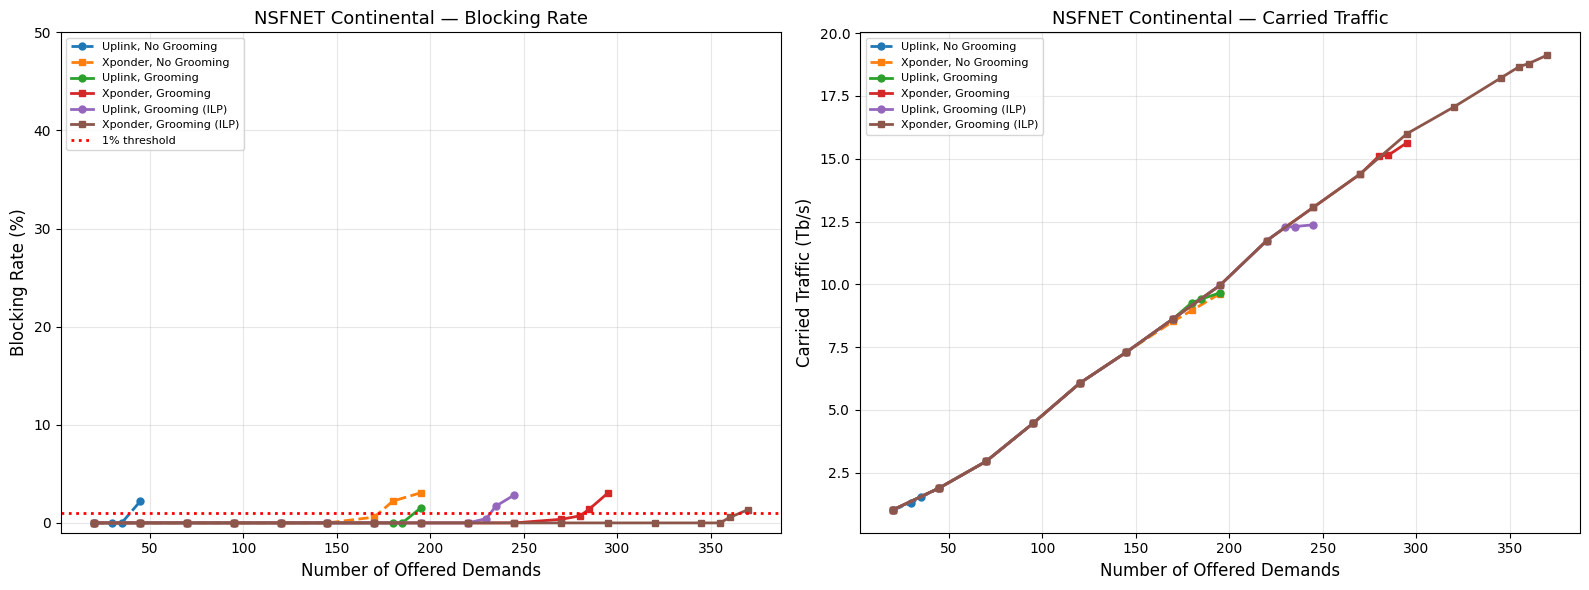

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Blocking rate
ax = axes[0]
for label, sw in nsf_sweeps.items():
    xs = sorted(set(r["num_demands"] for r in sw))
    ys = []
    for x in xs:
        rs = [r for r in sw if r["num_demands"] == x]
        ys.append(min(r["br"] for r in rs) * 100)
    style = "--" if "No Grooming" in label else "-"
    marker = "o" if "Uplink" in label else "s"
    ax.plot(xs, ys, style, marker=marker, label=label, markersize=5, linewidth=2)

ax.axhline(1.0, color="red", ls=":", lw=2, label="1% threshold")
ax.set_xlabel("Number of Offered Demands", fontsize=12)
ax.set_ylabel("Blocking Rate (%)", fontsize=12)
ax.set_title("NSFNET Continental — Blocking Rate", fontsize=13)
ax.legend(fontsize=8, loc="upper left")
ax.grid(True, alpha=0.3)
ax.set_ylim(-1, 50)

# Carried traffic
ax = axes[1]
for label, sw in nsf_sweeps.items():
    xs = sorted(set(r["num_demands"] for r in sw))
    ys = []
    for x in xs:
        rs = [r for r in sw if r["num_demands"] == x]
        ys.append(max(r["carried"] for r in rs) / 1000)
    style = "--" if "No Grooming" in label else "-"
    marker = "o" if "Uplink" in label else "s"
    ax.plot(xs, ys, style, marker=marker, label=label, markersize=5, linewidth=2)

ax.set_xlabel("Number of Offered Demands", fontsize=12)
ax.set_ylabel("Carried Traffic (Tb/s)", fontsize=12)
ax.set_title("NSFNET Continental — Carried Traffic", fontsize=13)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 5.4 Bottleneck Analysis (at maximum capacity point)

This shows per-node utilization of the three OTN constraints at the $N_{\max}$ point. The constraint that hits 100% first is the **bottleneck**.

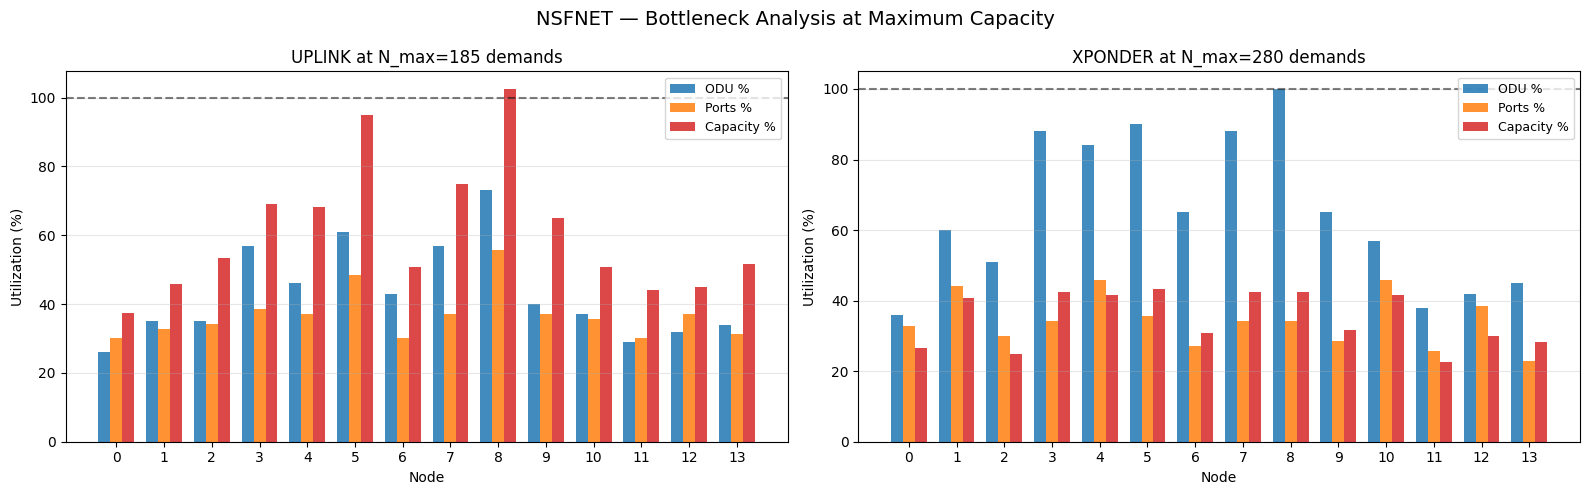

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for idx, key in enumerate(["Uplink, Grooming", "Xponder, Grooming"]):
    bn = nsf_results[key]["best"].get("bn", {})
    if not bn: continue

    ax = axes[idx]
    nodes_s = sorted(bn.keys())
    x = np.arange(len(nodes_s))
    w = 0.25

    odu = [bn[v]["odu"] for v in nodes_s]
    port = [bn[v]["ports"] for v in nodes_s]
    cap = [bn[v]["cap"] for v in nodes_s]

    ax.bar(x-w, odu, w, label="ODU %", color="tab:blue", alpha=0.85)
    ax.bar(x, port, w, label="Ports %", color="tab:orange", alpha=0.85)
    ax.bar(x+w, cap, w, label="Capacity %", color="tab:red", alpha=0.85)
    ax.axhline(100, color="black", ls="--", alpha=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels([str(v) for v in nodes_s])
    ax.set_xlabel("Node")
    ax.set_ylabel("Utilization (%)")
    scenario_name = "UPLINK" if "Uplink" in key else "XPONDER"
    nmax = nsf_results[key]["nmax"]
    ax.set_title(f"{scenario_name} at N_max={nmax} demands")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis="y")

plt.suptitle("NSFNET — Bottleneck Analysis at Maximum Capacity", fontsize=14)
plt.tight_layout()
plt.show()

## 6. Results — Italian National Network

### 6.1 Maximum Capacity Estimation

In [13]:
G_ita = italian()

configs_ita = [
    ("Uplink, No Grooming",     "uplink",  "heuristic", False),
    ("Xponder, No Grooming",    "xponder", "heuristic", False),
    ("Uplink, Grooming",        "uplink",  "heuristic", True),
    ("Xponder, Grooming",       "xponder", "heuristic", True),
    ("Uplink, Grooming (ILP)",  "uplink",  "ilp",       True),
    ("Xponder, Grooming (ILP)", "xponder", "ilp",       True),
]

ita_results = {}
ita_sweeps = {}

print("Italian National — Maximum Capacity Search")
print("=" * 80)

for label, scen, meth, groom in configs_ita:
    tl = 45 if meth == "ilp" else 60
    hi = 400 if meth == "ilp" else 1000
    nmax, best, sw = estimate_max_capacity(G_ita, scen, meth, groom,
                                            seed=SEED, lo=20, hi=hi, time_limit=tl)
    ita_results[label] = {"nmax": nmax, "best": best}
    ita_sweeps[label] = sw
    print(f"  {label:<30s} | N_max = {nmax:>4d} | BR = {best['br']:.2%} | "
          f"Carried = {best['carried']:.0f} Gb/s")

print("=" * 80)

Italian National — Maximum Capacity Search
  Uplink, No Grooming            | N_max =   20 | BR = 0.00% | Carried = 1100 Gb/s
  Xponder, No Grooming           | N_max =  110 | BR = 0.00% | Carried = 6500 Gb/s
  Uplink, Grooming               | N_max =  170 | BR = 0.59% | Carried = 9610 Gb/s
  Xponder, Grooming              | N_max =  180 | BR = 0.00% | Carried = 10260 Gb/s
  Uplink, Grooming (ILP)         | N_max =  105 | BR = 0.95% | Carried = 6080 Gb/s
  Xponder, Grooming (ILP)        | N_max =  185 | BR = 0.54% | Carried = 10480 Gb/s


### 6.2 Maximum Capacity Summary Table

In [14]:
print(f"{'─'*90}")
print(f"{'Configuration':<30s} │ {'N_max':>6s} │ {'Carried (Gb/s)':>14s} │ {'Carried (Tb/s)':>14s} │ {'Gain vs Uplink':>14s}")
print(f"{'─'*90}")

ref_u_ng = ita_results["Uplink, No Grooming"]["nmax"]
ref_u_g = ita_results["Uplink, Grooming"]["nmax"]

for label, data in ita_results.items():
    nmax = data["nmax"]
    carried = data["best"]["carried"]
    if "Xponder" in label:
        ref = ref_u_ng if "No Grooming" in label else ref_u_g
        gain = f"{(nmax/ref - 1)*100:>+.1f}%" if ref > 0 else "N/A"
    else:
        gain = "(baseline)"
    print(f"{label:<30s} │ {nmax:>6d} │ {carried:>14,.0f} │ {carried/1000:>14.1f} │ {gain:>14s}")

print(f"{'─'*90}")

──────────────────────────────────────────────────────────────────────────────────────────
Configuration                  │  N_max │ Carried (Gb/s) │ Carried (Tb/s) │ Gain vs Uplink
──────────────────────────────────────────────────────────────────────────────────────────
Uplink, No Grooming            │     20 │          1,100 │            1.1 │     (baseline)
Xponder, No Grooming           │    110 │          6,500 │            6.5 │        +450.0%
Uplink, Grooming               │    170 │          9,610 │            9.6 │     (baseline)
Xponder, Grooming              │    180 │         10,260 │           10.3 │          +5.9%
Uplink, Grooming (ILP)         │    105 │          6,080 │            6.1 │     (baseline)
Xponder, Grooming (ILP)        │    185 │         10,480 │           10.5 │          +8.8%
──────────────────────────────────────────────────────────────────────────────────────────


### 6.3 Blocking Rate and Carried Traffic

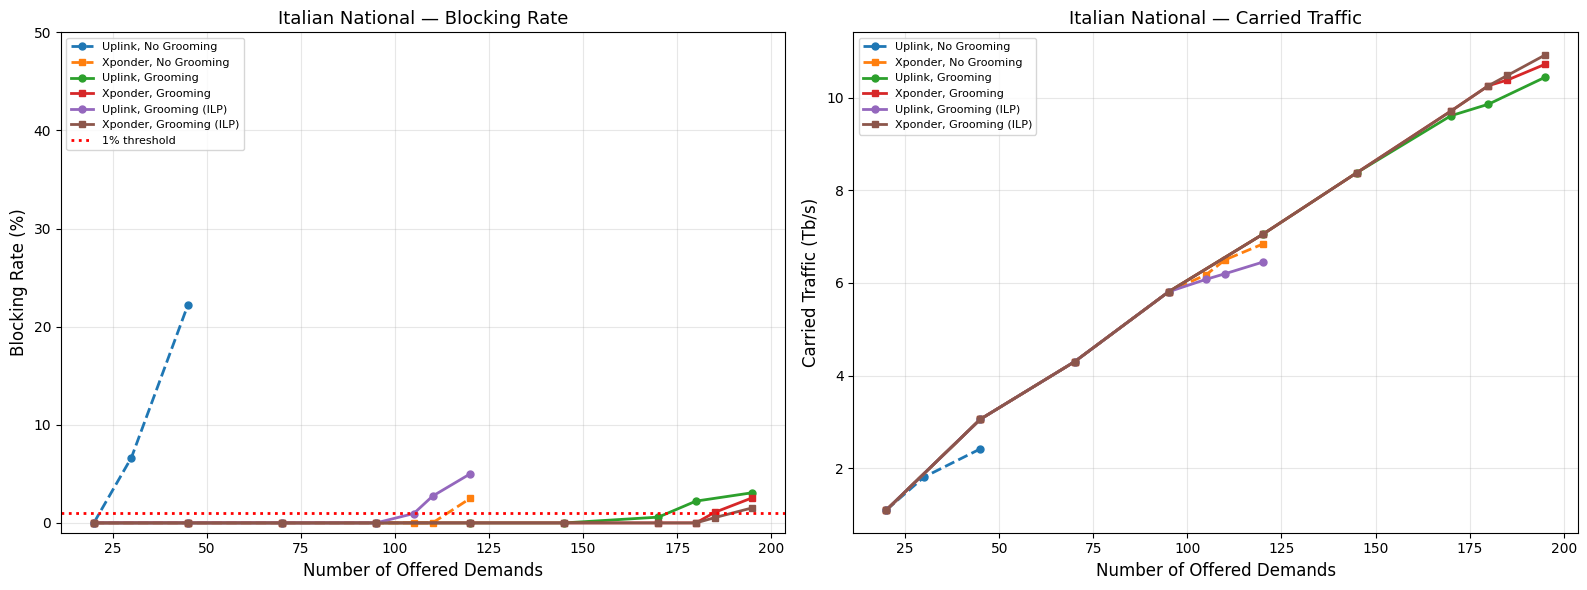

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
for label, sw in ita_sweeps.items():
    xs = sorted(set(r["num_demands"] for r in sw))
    ys = [min(r["br"] for r in sw if r["num_demands"]==x)*100 for x in xs]
    style = "--" if "No Grooming" in label else "-"
    marker = "o" if "Uplink" in label else "s"
    ax.plot(xs, ys, style, marker=marker, label=label, markersize=5, linewidth=2)
ax.axhline(1.0, color="red", ls=":", lw=2, label="1% threshold")
ax.set_xlabel("Number of Offered Demands", fontsize=12)
ax.set_ylabel("Blocking Rate (%)", fontsize=12)
ax.set_title("Italian National — Blocking Rate", fontsize=13)
ax.legend(fontsize=8, loc="upper left")
ax.grid(True, alpha=0.3)
ax.set_ylim(-1, 50)

ax = axes[1]
for label, sw in ita_sweeps.items():
    xs = sorted(set(r["num_demands"] for r in sw))
    ys = [max(r["carried"] for r in sw if r["num_demands"]==x)/1000 for x in xs]
    style = "--" if "No Grooming" in label else "-"
    marker = "o" if "Uplink" in label else "s"
    ax.plot(xs, ys, style, marker=marker, label=label, markersize=5, linewidth=2)
ax.set_xlabel("Number of Offered Demands", fontsize=12)
ax.set_ylabel("Carried Traffic (Tb/s)", fontsize=12)
ax.set_title("Italian National — Carried Traffic", fontsize=13)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 6.4 Bottleneck Analysis

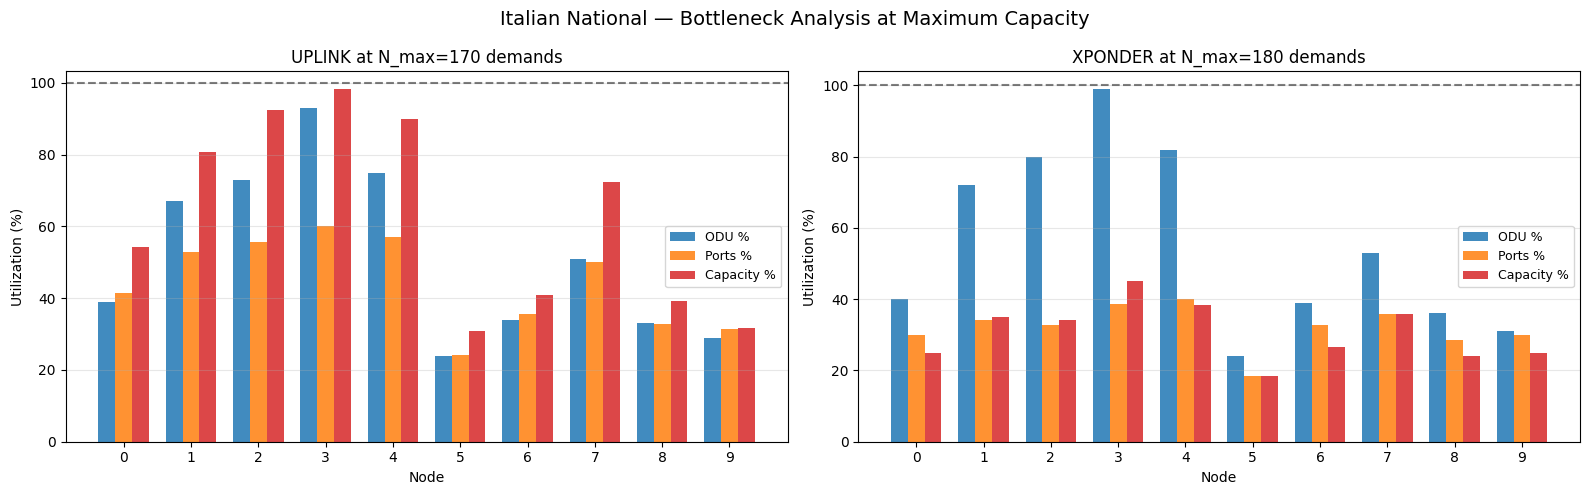

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for idx, key in enumerate(["Uplink, Grooming", "Xponder, Grooming"]):
    bn = ita_results[key]["best"].get("bn", {})
    if not bn: continue
    ax = axes[idx]
    nodes_s = sorted(bn.keys())
    x = np.arange(len(nodes_s))
    w = 0.25
    ax.bar(x-w, [bn[v]["odu"] for v in nodes_s], w, label="ODU %", color="tab:blue", alpha=0.85)
    ax.bar(x, [bn[v]["ports"] for v in nodes_s], w, label="Ports %", color="tab:orange", alpha=0.85)
    ax.bar(x+w, [bn[v]["cap"] for v in nodes_s], w, label="Capacity %", color="tab:red", alpha=0.85)
    ax.axhline(100, color="black", ls="--", alpha=0.5)
    ax.set_xticks(x); ax.set_xticklabels([str(v) for v in nodes_s])
    ax.set_xlabel("Node"); ax.set_ylabel("Utilization (%)")
    sn = "UPLINK" if "Uplink" in key else "XPONDER"
    ax.set_title(f"{sn} at N_max={ita_results[key]['nmax']} demands")
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis="y")

plt.suptitle("Italian National — Bottleneck Analysis at Maximum Capacity", fontsize=14)
plt.tight_layout()
plt.show()

## 7. Conclusion

### Which constraint has more impact?

| Network | Architecture | Binding Constraint | Why |
|---------|-------------|-------------------|-----|
| **NSFNET Continental** | Uplink | **OTN Switch Capacity** | Each uplink reserves 500 Gb/s; hub nodes saturate at ~24 uplinks |
| **NSFNET Continental** | Xponder | **ODU Limit** (100/node) | Capacity is efficient (1000 Gb/s per 10 xponders), but ODU processing limit is hit first |
| **Italian National** | Uplink | **OTN Capacity + ODU** | Shorter links allow higher lightpath rates, but small network concentrates traffic on hub nodes |
| **Italian National** | Xponder | **ODU Limit** | Same as NSFNET — ODU is the universal bottleneck for Xponder |

### Is it better to use a Muxponder or an Uplink?

**Yes, the Xponder (Muxponder) consistently achieves higher network capacity**, particularly on the continental network where:

1. **Without grooming**: Xponder supports significantly more services than Uplink because each xponder I/O card (1000 Gb/s, 10 slots) is far more port- and capacity-efficient than individual uplinks (500 Gb/s each).

2. **With grooming**: The gap narrows because grooming reduces the number of lightpaths (and hence transponders) needed. However, Xponder still carries more traffic at the same acceptance level because it has more capacity headroom to create additional lightpaths when needed.

3. **On the national network**: The advantage diminishes because the **ODU processing limit** (100 per node) becomes the binding constraint for both architectures. Since ODUs are independent of the transponder type, Uplink and Xponder converge.

### Grooming Impact

Grooming is the single most impactful design choice — it increases maximum capacity by **4-5×** for Uplink and **2-3×** for Xponder on the continental network. The effect is larger for Uplink because without grooming, each 10G demand wastes an entire lightpath (and thus an entire uplink slot).